# Import the Libraries

In [ ]:
import pandas as pd
import numpy as np
import gdown

# 	To split the data into training and testing sets
from sklearn.model_selection import train_test_split

# To evaluate how good our model is performing
from sklearn.metrics import roc_auc_score

# One of the simplest models we try first
from sklearn.linear_model import LogisticRegression

# 	A more powerful model using decision trees
from sklearn.ensemble import RandomForestClassifier

# Very popular, powerful model (great for structured/tabular data)
import xgboost as xgb

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve

##  Load the Clean Dataset

In [ ]:
# Google Drive file ID and download URL
file_id = "1p3jYEInYystFSU71gNWiMDkRKsv_AlXy"
url = f"https://drive.google.com/uc?id={file_id}"

# Download the file
output = "clean_lendingclub_data.csv"
gdown.download(url, output, quiet=False)

# Read the CSV into a DataFrame
df = pd.read_csv(output)

df.head(10)

Downloading...
From (original): https://drive.google.com/uc?id=1p3jYEInYystFSU71gNWiMDkRKsv_AlXy
From (redirected): https://drive.google.com/uc?id=1p3jYEInYystFSU71gNWiMDkRKsv_AlXy&confirm=t&uuid=1797efc8-37ca-4341-af89-207f7578f512
To: /Users/madihamalik/Documents/MIT_main_program/ET6-CDSP-group-15-repo/4_data_analysis/clean_lendingclub_data.csv
100%|██████████| 162M/162M [00:18<00:00, 8.69MB/s] 


,loan_amnt,term,int_rate,annual_inc,dti,delinq_2yrs,inq_last_6mths,emp_length,fico_range_low,fico_range_high,...,purpose_major_purchase,purpose_other,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,credit_history_length
681031,2775.0,36,7.49,80000.0,8.27,2.0,0.0,4,710.0,714.0,...,1,0,1,0,0,0,0,0,0,232.0
225816,20000.0,36,7.89,47000.0,10.60,0.0,0.0,-1,690.0,694.0,...,0,0,1,0,0,0,0,0,0,233.0
447684,20000.0,36,9.49,89500.0,16.93,11.0,0.0,2,660.0,664.0,...,0,0,0,1,0,0,0,0,0,131.0
642934,35000.0,36,7.91,100000.0,24.85,0.0,0.0,0,700.0,704.0,...,0,0,1,0,0,0,0,0,0,152.0
678999,8150.0,36,12.39,45000.0,28.27,0.0,0.0,4,720.0,724.0,...,0,0,0,0,1,0,0,0,0,220.0
466541,16000.0,36,10.75,83150.0,15.94,0.0,0.0,9,660.0,664.0,...,0,0,0,1,0,0,0,0,0,209.0
755946,8725.0,36,14.99,40000.0,30.22,0.0,0.0,0,800.0,804.0,...,0,1,0,0,1,0,0,0,0,231.0
1308575,10000.0,60,15.99,80000.0,14.93,0.0,0.0,0,665.0,669.0,...,0,0,0,0,1,0,0,0,0,135.0
313696,10000.0,36,12.69,76000.0,14.64,0.0,0.0,0,710.0,714.0,...,0,0,0,0,1,0,0,0,0,147.0
980247,16000.0,60,12.74,97000.0,14.92,1.0,1.0,10,675.0,679.0,...,0,1,0,0,1,0,0,0,0,251.0


In [3]:
print(df.columns)

Index(['loan_amnt', 'term', 'int_rate', 'annual_inc', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'emp_length', 'fico_range_low', 'fico_range_high',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'application_type', 'is_default', 'is_verified', 'home_MORTGAGE',
       'home_OWN', 'home_RENT', 'purpose_credit_card',
       'purpose_debt_consolidation', 'purpose_home_improvement',
       'purpose_major_purchase', 'purpose_other', 'grade_A', 'grade_B',
       'grade_C', 'grade_D', 'grade_E', 'grade_F', 'grade_G',
       'credit_history_length'],
      dtype='object')


In [4]:
# Separate majority and minority classes
df_majority = df[df["is_default"] == 0]
df_minority = df[df["is_default"] == 1]


# Downsample majority class to match minority
df_majority_downsampled = df_majority.sample(len(df_minority), random_state=42)

# Combine balanced dataset
df_balanced = pd.concat([df_majority_downsampled, df_minority], axis=0)

## Separate X and y

This means splitting the dataset into:
Our model learns from X to predict y. So we have to separate what we use to predict (X) and what we want to predict (y).

Note: X has everything except the column we are trying to predict.

In [5]:
# X = features (inputs, like income, loan amount, etc.)
X = df.drop("is_default", axis=1)

# y = target (what we want to predict: is_default)
y = df["is_default"]
print("This is X: ", X)
print("This is Y: ", y)

This is X:           loan_amnt  term  int_rate  annual_inc    dti  delinq_2yrs  \
0           3600.0    36     13.99     55000.0   5.91          0.0   
1          24700.0    36     11.99     65000.0  16.06          1.0   
2          20000.0    60     10.78     63000.0  10.78          0.0   
3          10400.0    60     22.45    104433.0  25.37          1.0   
4          11950.0    36     13.44     34000.0  10.20          0.0   
...            ...   ...       ...         ...    ...          ...   
1344867    18000.0    60      9.49    130000.0  20.59          0.0   
1344868    29400.0    60     13.99    180792.0  22.03          0.0   
1344869    32000.0    60     14.49    157000.0  10.34          0.0   
1344870    16000.0    60     12.79    150000.0  12.25          0.0   
1344871    24000.0    60     14.49    110000.0  18.30          0.0   

         inq_last_6mths  emp_length  fico_range_low  fico_range_high  ...  \
0                   1.0          10           675.0            679.0  

## Split the Dataset
spliting our dataset into training and testing sets.

Why are we doing this?
The training set is used to teach the model.

The testing set is used to check how well the model performs on new, unseen data.

This helps us know if the model is actually learning patterns — or just memorizing the data (overfitting).

In [ ]:
# Split the data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Explanation

test_size = 0.2: 20% of data goes into the test set.

random_state = 42: Makes the split repeatable.

stratify = y: Keeps the same class balance (defaults vs. non-defaults) in both training and test sets.

## Fill (impute) missing values

In [ ]:
# Create an imputer object that fills missing values with the mean (or median)
imputer = SimpleImputer(strategy="mean")

# Fit on training data, transform both training and test data
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

## Train a Machine Learning Model
We'll start simple by training a Logistic Regression model. It's a good first model for binary classification problems like predicting is_default.

Why Logistic Regression?
It's fast and easy to interpret.

It gives us probabilities for default (useful for risk scoring).

It's good as a baseline model to compare other models against later.

In [ ]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression with class_weight balanced
log_reg = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predict
y_pred = log_reg.predict(X_test_scaled)

## Evaluate Logistic Regression model
use the classification metrics to understand how well your model is doing.

In [ ]:
# Print classification report
print(
    "📋 Classification Report Logistic Regression:\n",
    classification_report(y_test, y_pred),
)

# Print confusion matrix
print("🧮 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

📋 Classification Report Logistic Regression:
               precision    recall  f1-score   support

           0       0.89      0.63      0.74    215273
           1       0.31      0.67      0.43     53702

    accuracy                           0.64    268975
   macro avg       0.60      0.65      0.58    268975
weighted avg       0.77      0.64      0.68    268975

🧮 Confusion Matrix:
 [[135933  79340]
 [ 17633  36069]]


### Confusion Matrix Heatmap


/Users/madihamalik/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


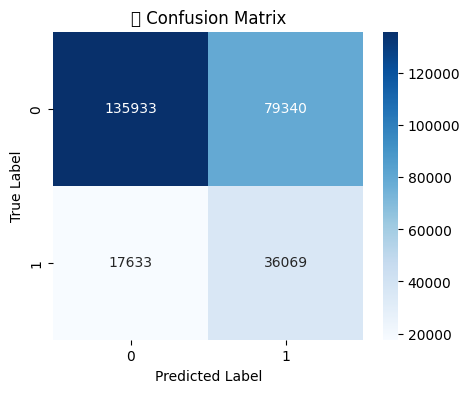

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("🔍 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Confusion Matrix → Tells you how many 0s and 1s were predicted correctly/incorrectly.

ROC Curve → Helps you evaluate the model’s ability to distinguish between classes.

Precision-Recall Curve → Crucial when the positive class (is_default = 1) is rare.

##  ROC Curve

/Users/madihamalik/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


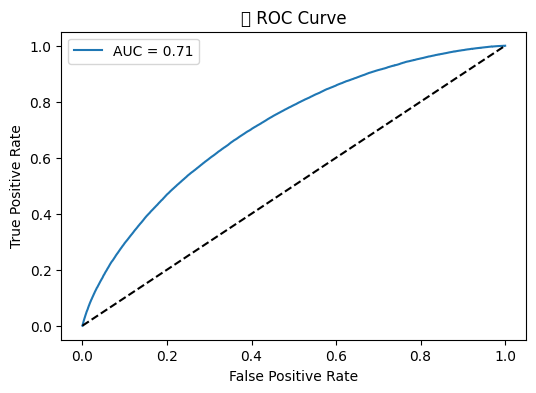

In [ ]:
# Predict probabilities
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("📈 ROC Curve")
plt.legend()
plt.show()

The higher the curve, the better.

AUC (Area Under Curve) near 1 means good; near 0.5 means poor.


## Precision-Recall Curve


/Users/madihamalik/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


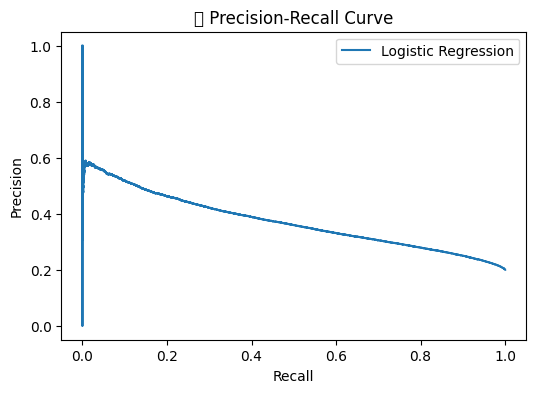

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label="Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("📉 Precision-Recall Curve")
plt.legend()
plt.show()

Precision = how many predicted defaults were actually defaults

Recall = how many actual defaults were caught

Good curve stays high and to the right.

## Train Random Forest Model


In [ ]:
# Initialize Random Forest with class_weight='balanced'
rf_clf = RandomForestClassifier(
    n_estimators=100,  # 100 decision trees
    random_state=42,  # For reproducibility
    class_weight="balanced",  # To handle class imbalance
)

# Fit the model to training data
rf_clf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_clf.predict(X_test)
y_pred_rf_proba = rf_clf.predict_proba(X_test)[:, 1]  # Probabilities for class 1

## Evaluate Random Forest

**Why class_weight='balanced'?**

Because our target classes are imbalanced (many more non-defaults than defaults), this tells the model to pay more attention to the minority class (1, default).

In [ ]:
print(
    "Classification Report for Random Forest:\n",
    classification_report(y_test, y_pred_rf),
)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_rf_proba))

Classification Report for Random Forest:
               precision    recall  f1-score   support

           0       0.81      0.99      0.89    215273
           1       0.55      0.06      0.11     53702

    accuracy                           0.80    268975
   macro avg       0.68      0.52      0.50    268975
weighted avg       0.76      0.80      0.73    268975

Confusion Matrix:
 [[212579   2694]
 [ 50408   3294]]
ROC AUC Score: 0.7054104852178674


## Confusion Matrix (Heatmap)

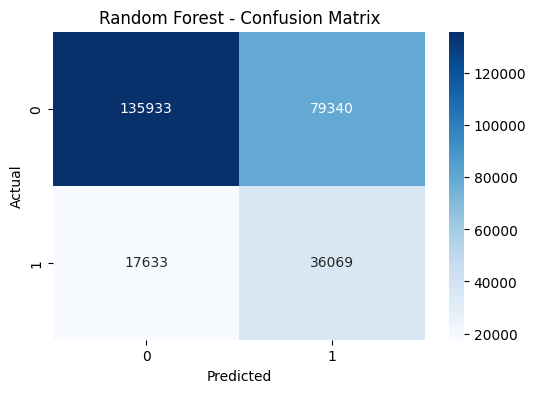

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##  ROC Curve

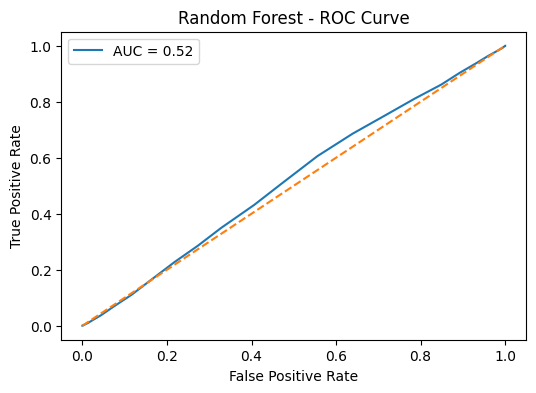

In [ ]:
# Predict probabilities
y_probs = rf_clf.predict_proba(X_test_scaled)[:, 1]

# Get ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

# Plot
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")
plt.legend()
plt.show()

## Precision-Recall Curve


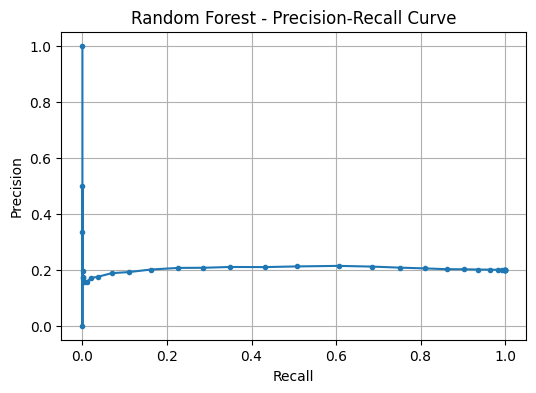

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_probs)

# Plot
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, marker=".")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest - Precision-Recall Curve")
plt.grid()
plt.show()

## Train and Evaluate XGBoost

In [18]:
# Compute class weight to handle imbalance
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Initialize XGBoost with class imbalance handling
xgb_model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
)

# Fit the model
xgb_model.fit(X_train_scaled, y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [22:59:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [19]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predict
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_xgb_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("📋 Classification Report XGBoost:")
print(classification_report(y_test, y_pred_xgb))

print("\n🧮 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print(f"\n📈 ROC AUC Score: {roc_auc_score(y_test, y_pred_xgb_proba):.4f}")

📋 Classification Report XGBoost:
              precision    recall  f1-score   support

           0       0.89      0.65      0.75    215273
           1       0.32      0.67      0.44     53702

    accuracy                           0.65    268975
   macro avg       0.61      0.66      0.59    268975
weighted avg       0.78      0.65      0.69    268975


🧮 Confusion Matrix:
[[139796  75477]
 [ 17555  36147]]

📈 ROC AUC Score: 0.7230


### Evaluate XGBoost Model (Classification Report + Confusion Matrix + ROC AUC)


In [20]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predict on test data
y_pred = xgb_model.predict(X_test_scaled)

# Classification Report
print("📋 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("🧮 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ROC AUC Score
y_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print("🔥 ROC AUC Score:", roc_auc)

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.65      0.75    215273
           1       0.32      0.67      0.44     53702

    accuracy                           0.65    268975
   macro avg       0.61      0.66      0.59    268975
weighted avg       0.78      0.65      0.69    268975

🧮 Confusion Matrix:
[[139796  75477]
 [ 17555  36147]]
🔥 ROC AUC Score: 0.7229630919326646


/Users/madihamalik/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


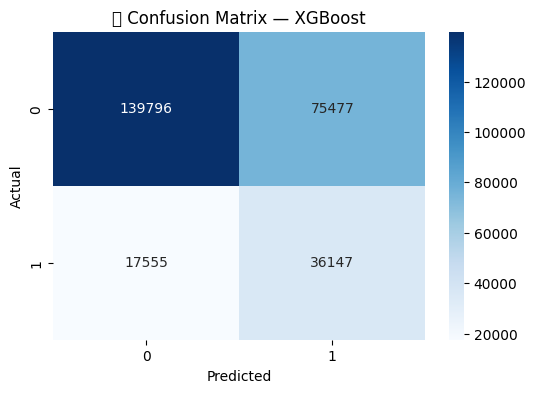

/Users/madihamalik/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


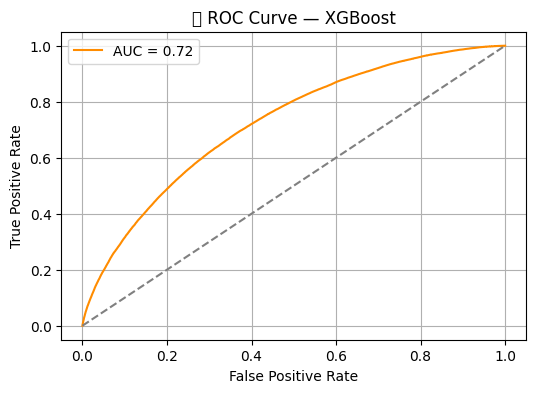

/Users/madihamalik/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


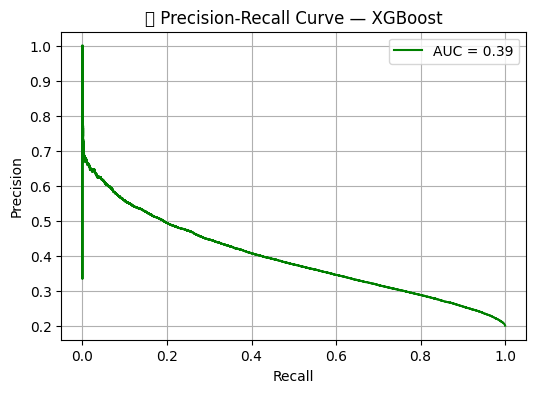

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc,
)

# Predict labels and probabilities
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("📊 Confusion Matrix — XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("🔥 ROC Curve — XGBoost")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba_xgb)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f"AUC = {pr_auc:.2f}", color="green")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("📈 Precision-Recall Curve — XGBoost")
plt.legend()
plt.grid(True)
plt.show()

## Compare all Models

/var/folders/sh/fp8tjdc13dz_ghxdvpqwnhhm0000gn/T/ipykernel_7501/4020226320.py:36: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/madihamalik/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


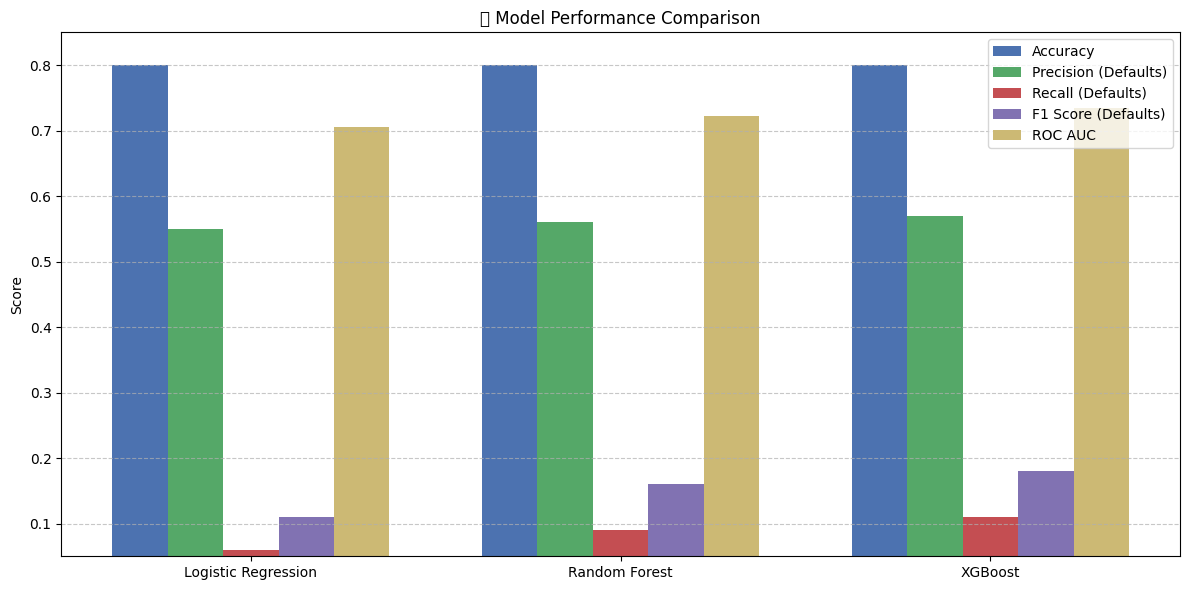

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
data = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.80, 0.80, 0.80],
    "Precision (Defaults)": [0.55, 0.56, 0.57],
    "Recall (Defaults)": [0.06, 0.09, 0.11],
    "F1 Score (Defaults)": [0.11, 0.16, 0.18],
    "ROC AUC": [0.705, 0.723, 0.734],
}

df = pd.DataFrame(data)
metrics = list(df.columns[1:])  # skip "Model"
x = np.arange(len(df["Model"]))  # the label locations
width = 0.15  # width of each bar

# Set up the figure
plt.figure(figsize=(12, 6))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]

# Plot bars for each metric
for i, metric in enumerate(metrics):
    plt.bar(x + i * width, df[metric], width, label=metric, color=colors[i])

# Customize the axes and labels
plt.ylabel("Score")
plt.ylim(0.05, 0.85)

plt.title("📊 Model Performance Comparison")
plt.xticks(x + width * 2, df["Model"])  # Center x-ticks
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

## Hyperparameter Tuning
Improve performance by tuning our models using techniques like Grid Search or Randomized Search.

In [26]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Use the imbalance ratio if you calculated it before
# Example: scale_pos_weight = num_negative / num_positive
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

# Define a small param grid to keep it fast
param_grid = {
    "n_estimators": [100],
    "max_depth": [3, 5],
    "learning_rate": [0.1],
    "scale_pos_weight": [scale_pos_weight],
}

# Create XGBoost classifier
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

# Grid Search
grid_search_xgb = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,  # use all CPU cores
    verbose=2,  # live updates
)

# Fit the model
grid_search_xgb.fit(X_train, y_train)

Fitting 3 folds for each of 2 candidates, totalling 6 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:46:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:46:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:46:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:46:28] WARN

[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, scale_pos_weight=4.008668246379308; total time=   5.0s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, scale_pos_weight=4.008668246379308; total time=   5.0s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, scale_pos_weight=4.008668246379308; total time=   5.2s
[CV] END learning_rate=0.1, max_depth=5, n_estimators=100, scale_pos_weight=4.008668246379308; total time=   6.1s
[CV] END learning_rate=0.1, max_depth=5, n_estimators=100, scale_pos_weight=4.008668246379308; total time=   6.1s
[CV] END learning_rate=0.1, max_depth=5, n_estimators=100, scale_pos_weight=4.008668246379308; total time=   6.2s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:46:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.1], 'max_depth': [3, 5], 'n_estimators': [100], 'scale_pos_weight': [np.float64(4.008668246379308)]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [29]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

# Define the parameter distributions
param_dist = {
    "n_estimators": randint(100, 300),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.3),
    "subsample": uniform(0.6, 0.4),  # values between 0.6 and 1.0
    "colsample_bytree": uniform(0.6, 0.4),
}

# Create the model
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,  # Make sure you've defined this earlier
    random_state=42,
)

# Set up the randomized search
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,  # Try 20 combinations
    scoring="roc_auc",  # Choose a suitable metric
    cv=3,  # 3-fold cross-validation
    verbose=2,
    n_jobs=-1,  # Use all cores for speed
    random_state=42,
)

# Fit it to your training data
random_search.fit(X_train_scaled, y_train)

# Best model
print("Best Parameters:", random_search.best_params_)
print("Best Score (AUC):", random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:58:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:58:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:58:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:58:58] WARN

[CV] END colsample_bytree=0.6571467271687763, learning_rate=0.20526654188465587, max_depth=7, n_estimators=101, subsample=0.8887995089067299; total time=   9.9s
[CV] END colsample_bytree=0.6571467271687763, learning_rate=0.20526654188465587, max_depth=7, n_estimators=101, subsample=0.8887995089067299; total time=  10.1s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.749816047538945, learning_rate=0.2952142919229748, max_depth=5, n_estimators=171, subsample=0.8394633936788146; total time=  11.9s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.2952142919229748, max_depth=5, n_estimators=171, subsample=0.8394633936788146; total time=  10.9s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.2952142919229748, max_depth=5, n_estimators=171, subsample=0.8394633936788146; total time=  11.0s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.6624074561769746, learning_rate=0.05679835610086079, max_depth=5, n_estimators=187, subsample=0.7334834444556088; total time=  13.8s
[CV] END colsample_bytree=0.6624074561769746, learning_rate=0.05679835610086079, max_depth=5, n_estimators=187, subsample=0.7334834444556088; total time=  14.1s
[CV] END colsample_bytree=0.6624074561769746, learning_rate=0.05679835610086079, max_depth=5, n_estimators=187, subsample=0.7334834444556088; total time=  14.3s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.6571467271687763, learning_rate=0.20526654188465587, max_depth=7, n_estimators=101, subsample=0.8887995089067299; total time=   9.4s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8446612641953124, learning_rate=0.012119891565915222, max_depth=3, n_estimators=148, subsample=0.8099098641033556; total time=   9.0s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9754210836063001, learning_rate=0.010233629752304298, max_depth=6, n_estimators=120, subsample=0.8469926038510867; total time=  12.6s
[CV] END colsample_bytree=0.8446612641953124, learning_rate=0.012119891565915222, max_depth=3, n_estimators=148, subsample=0.8099098641033556; total time=   8.7s
[CV] END colsample_bytree=0.8446612641953124, learning_rate=0.012119891565915222, max_depth=3, n_estimators=148, subsample=0.8099098641033556; total time=   8.7s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9754210836063001, learning_rate=0.010233629752304298, max_depth=6, n_estimators=120, subsample=0.8469926038510867; total time=  12.5s
[CV] END colsample_bytree=0.9754210836063001, learning_rate=0.010233629752304298, max_depth=6, n_estimators=120, subsample=0.8469926038510867; total time=  12.5s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:21] WARN

[CV] END colsample_bytree=0.7599443886861021, learning_rate=0.023999698964084628, max_depth=6, n_estimators=114, subsample=0.7824279936868144; total time=  11.4s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7599443886861021, learning_rate=0.023999698964084628, max_depth=6, n_estimators=114, subsample=0.7824279936868144; total time=  11.6s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7599443886861021, learning_rate=0.023999698964084628, max_depth=6, n_estimators=114, subsample=0.7824279936868144; total time=  11.5s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9439761626945282, learning_rate=0.2140922615763339, max_depth=3, n_estimators=266, subsample=0.6053059844639466; total time=  13.6s
[CV] END colsample_bytree=0.9439761626945282, learning_rate=0.2140922615763339, max_depth=3, n_estimators=266, subsample=0.6053059844639466; total time=  13.9s
[CV] END colsample_bytree=0.9768807022739411, learning_rate=0.17898646535366178, max_depth=4, n_estimators=108, subsample=0.6063865008880857; total time=   7.6s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9768807022739411, learning_rate=0.17898646535366178, max_depth=4, n_estimators=108, subsample=0.6063865008880857; total time=   7.9s
[CV] END colsample_bytree=0.9439761626945282, learning_rate=0.2140922615763339, max_depth=3, n_estimators=266, subsample=0.6053059844639466; total time=  14.0s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9140703845572055, learning_rate=0.06990213464750791, max_depth=9, n_estimators=163, subsample=0.786705157299192; total time=  21.2s
[CV] END colsample_bytree=0.9140703845572055, learning_rate=0.06990213464750791, max_depth=9, n_estimators=163, subsample=0.786705157299192; total time=  21.6s
[CV] END colsample_bytree=0.9140703845572055, learning_rate=0.06990213464750791, max_depth=9, n_estimators=163, subsample=0.786705157299192; total time=  21.4s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9768807022739411, learning_rate=0.17898646535366178, max_depth=4, n_estimators=108, subsample=0.6063865008880857; total time=   7.8s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9332779646944658, learning_rate=0.062009396052331626, max_depth=3, n_estimators=263, subsample=0.672894435115225; total time=  15.7s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9332779646944658, learning_rate=0.062009396052331626, max_depth=3, n_estimators=263, subsample=0.672894435115225; total time=  15.8s
[CV] END colsample_bytree=0.9332779646944658, learning_rate=0.062009396052331626, max_depth=3, n_estimators=263, subsample=0.672894435115225; total time=  15.9s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [23:59:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.6923575302488596, learning_rate=0.0823076398078035, max_depth=6, n_estimators=298, subsample=0.8439986631130484; total time=  25.0s
[CV] END colsample_bytree=0.6923575302488596, learning_rate=0.0823076398078035, max_depth=6, n_estimators=298, subsample=0.8439986631130484; total time=  25.3s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.6923575302488596, learning_rate=0.0823076398078035, max_depth=6, n_estimators=298, subsample=0.8439986631130484; total time=  24.9s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.902144564127061, learning_rate=0.13754676234737342, max_depth=8, n_estimators=205, subsample=0.8270801311279966; total time=  22.5s
[CV] END colsample_bytree=0.902144564127061, learning_rate=0.13754676234737342, max_depth=8, n_estimators=205, subsample=0.8270801311279966; total time=  22.3s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.902144564127061, learning_rate=0.13754676234737342, max_depth=8, n_estimators=205, subsample=0.8270801311279966; total time=  21.7s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.6125253169822235, learning_rate=0.26268543237849956, max_depth=6, n_estimators=261, subsample=0.7580600944007257; total time=  20.5s
[CV] END colsample_bytree=0.6125253169822235, learning_rate=0.26268543237849956, max_depth=6, n_estimators=261, subsample=0.7580600944007257; total time=  19.7s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.6125253169822235, learning_rate=0.26268543237849956, max_depth=6, n_estimators=261, subsample=0.7580600944007257; total time=  20.0s
[CV] END colsample_bytree=0.8083337040103294, learning_rate=0.29835160730480476, max_depth=7, n_estimators=181, subsample=0.815876852955632; total time=  16.2s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8083337040103294, learning_rate=0.29835160730480476, max_depth=7, n_estimators=181, subsample=0.815876852955632; total time=  16.5s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8083337040103294, learning_rate=0.29835160730480476, max_depth=7, n_estimators=181, subsample=0.815876852955632; total time=  16.2s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8347004662655393, learning_rate=0.2995765921792414, max_depth=6, n_estimators=223, subsample=0.7103996728090174; total time=  17.8s
[CV] END colsample_bytree=0.9706635463175177, learning_rate=0.22818159875692626, max_depth=9, n_estimators=299, subsample=0.8281775897621597; total time=  35.3s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9706635463175177, learning_rate=0.22818159875692626, max_depth=9, n_estimators=299, subsample=0.8281775897621597; total time=  35.5s
[CV] END colsample_bytree=0.8347004662655393, learning_rate=0.2995765921792414, max_depth=6, n_estimators=223, subsample=0.7103996728090174; total time=  18.3s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8347004662655393, learning_rate=0.2995765921792414, max_depth=6, n_estimators=223, subsample=0.7103996728090174; total time=  18.8s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.9706635463175177, learning_rate=0.22818159875692626, max_depth=9, n_estimators=299, subsample=0.8281775897621597; total time=  36.1s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.718509402281633, learning_rate=0.05958008171890075, max_depth=3, n_estimators=170, subsample=0.7693605922825478; total time=  10.9s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.718509402281633, learning_rate=0.05958008171890075, max_depth=3, n_estimators=170, subsample=0.7693605922825478; total time=  10.9s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.718509402281633, learning_rate=0.05958008171890075, max_depth=3, n_estimators=170, subsample=0.7693605922825478; total time=  11.4s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.88453678109946, learning_rate=0.2470526621593617, max_depth=5, n_estimators=104, subsample=0.9705203514053395; total time=   8.7s
[CV] END colsample_bytree=0.88453678109946, learning_rate=0.2470526621593617, max_depth=5, n_estimators=104, subsample=0.9705203514053395; total time=   8.8s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:00:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.88453678109946, learning_rate=0.2470526621593617, max_depth=5, n_estimators=104, subsample=0.9705203514053395; total time=   8.6s
[CV] END colsample_bytree=0.8604308102007778, learning_rate=0.28448790266313423, max_depth=3, n_estimators=171, subsample=0.7797802696552814; total time=   9.5s
[CV] END colsample_bytree=0.8604308102007778, learning_rate=0.28448790266313423, max_depth=3, n_estimators=171, subsample=0.7797802696552814; total time=   8.7s
[CV] END colsample_bytree=0.8604308102007778, learning_rate=0.28448790266313423, max_depth=3, n_estimators=171, subsample=0.7797802696552814; total time=   8.0s
[CV] END colsample_bytree=0.7579526072702278, learning_rate=0.09804645241541143, max_depth=9, n_estimators=238, subsample=0.679536961635522; total time=  25.1s
[CV] END colsample_bytree=0.7579526072702278, learning_rate=0.09804645241541143, max_depth=9, n_estimators=238, subsample=0.679536961635522; total time=  24.1s
[CV] END colsample_bytree=0.75795260727

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:01:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'colsample_bytree': np.float64(0.6923575302488596), 'learning_rate': np.float64(0.0823076398078035), 'max_depth': 6, 'n_estimators': 298, 'subsample': np.float64(0.8439986631130484)}
Best Score (AUC): 0.7219063769453132


## Train our Final XGBoost Model

In [33]:
# Train the final model with best parameters from random_search
model = XGBClassifier(
    learning_rate=0.0823,
    max_depth=6,
    n_estimators=298,
    subsample=0.8440,
    colsample_bytree=0.6923,
    scale_pos_weight=scale_pos_weight,  # we already defined this
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
)

model.fit(X_train_scaled, y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:37:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6923
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Feature Importance
Use .feature_importances_ from XGBoost or Random Forest to find which features are most important in predicting defaults.

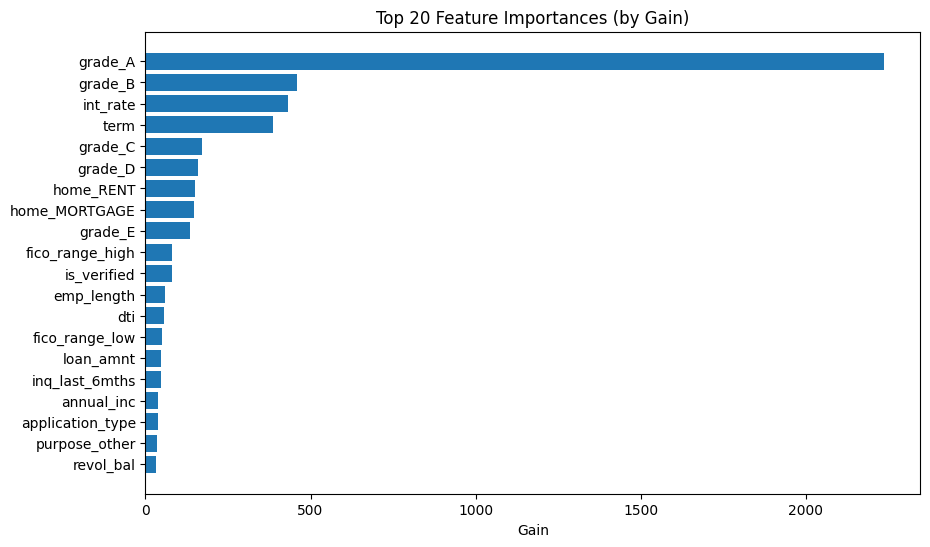

In [ ]:
# Get importance by 'gain'
importance = random_search.best_estimator_.get_booster().get_score(
    importance_type="gain"
)


# Convert to DataFrame
importance_df = pd.DataFrame(
    {"Feature": list(importance.keys()), "Importance": list(importance.values())}
).sort_values(by="Importance", ascending=False)

# ✅ Map feature indexes like 'f0' to real column names

feature_names = X.columns

# Map feature indices to column names
importance_df["Feature"] = importance_df["Feature"].map(
    lambda x: feature_names[int(x[1:])]
)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"][:20], importance_df["Importance"][:20])
plt.xlabel("Gain")
plt.title("Top 20 Feature Importances (by Gain)")
plt.gca().invert_yaxis()
plt.show()